In [15]:
from dotenv import load_dotenv
import os
load_dotenv(override=True)
from langchain_openai import ChatOpenAI
from langgraph.types import interrupt
from typing import Literal

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [2]:
openai_key = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_key,
    temperature=0,
    max_tokens=None,
    max_retries=2
)

In [3]:
response = llm.invoke("Who started World War 3")
print("Response: ", response.content)

Response:  As of my last knowledge update in October 2023, there has not been a World War III. While there have been numerous conflicts and tensions around the world, no event has escalated to the level of a global war comparable to World War I or World War II. If you are referring to a specific event or hypothetical scenario, please provide more details, and I would be happy to discuss it further.


In [4]:
topics = [{
    "name": "Small Business Defined",
    "notes": f"""Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. 
    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes
    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities."""
    },
    {
    "name": "Small Business Impact",
    "notes": f"""There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created 
    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses rebounded quickly,
    demonstrating their resilience and importance to economic recovery. They contribute to local economies by reinvesting paychecks and taxes, supporting 
    new businesses, and improving
    public services. On average, small businesses offer competitive wages, averaging $30.42 per hour, translating to an annual income of $63,000."""
    },
    {
    "name": "Small Business Demographics",
    "notes": f"""43.4% of small businesses are owned by females, reflecting progress toward gender equality in entrepreneurship.
    20.4% are owned by racial minorities, including 14.5% by Hispanics.
    6.1% are owned by veterans, contributing diverse perspectives to the U.S. economy.
    Hispanic-owned businesses, for example, pay over $100 billion annually in payroll to their 1 million workers."""
    }
    ]

In [14]:
from pydantic import BaseModel, Field

class MCQ(BaseModel):
    question: str
    options: list[str]
    answer: str
    explanation: str

class TrueFalse(BaseModel):
    question: str
    answer: bool
    explanation: str

class QuizSchema(BaseModel):
    mcq: list[MCQ]
    true_false: list[TrueFalse]

In [6]:
from typing import TypedDict, List

class ConceptState(MessagesState):
    topic: str
    notes: str
    quizzes: list[Quiz]
    report: str

In [7]:
class DialogueState(MessagesState):
    index: int
    dialogues: list[ConceptState]
    llm: str

### Update the index to set the next topic in dialogue

In [8]:
def set_topic_index(state: DialogueState) -> DialogueState:
    state[index] += 1
    return state

### Check if there are topics remaining

In [9]:
def remaining(state: DialogueState) -> bool:
    return state["index"] < len(state["dialogues"]) 

### Prepare an AI summary of the concept

In [10]:
def concept_summary(state: DialogueState) -> DialogueState:
    """LLM should prepare a friendly summary on the topic."""
    
    context = "\n".join([topic["notes"] for topic in state["dialogues"]])
    
    concept_prompt = f"""
    Prepare a summary on the topic. Use notes for preparing summary and
    context information as overall context while preparing the conceptual summary.
    Topic: {state["dialogues"][state["index"]]["topic"]}
    Notes: {state["dialogues"][state["index"]]["notes"]}
    Context: {context}

    Output Sample: <b>Topic</b> - How to get rich in 100 days? <p>There are many ways, best
    path is to work hard....</p>
    """
    summary = llm.invoke(concept_prompt).content
    state["dialogues"][state["index"]]["messages"].append(AIMessage(content=summary))
    return state
    

### Get the users rely

In [20]:
def get_user_reply(state: DialogueState) -> DialogueState:
    summary = state["dialogues"][state["index"]]["messages"][-1].content
    user_reply = interrupt(
        f"{summary}. Any doubts?" 
    )
    state["dialogues"][state["index"]]["messages"].append(HumanMessage(content=user_reply))
    return state
    

### Evaluluate whether a user want clarity of want to proceed with quiz

In [18]:
def reply_intent(state: DialogueState) -> Literal["hint", "clear"]:
    user_reply = state["dialogues"][state["index"]]["user_reply"]
    intent_prompt = f"""Look at the users latest reply and check the intent of the user. Check if user want more clarity or is
    clear on a given concept. Only return "hint" or "clear".
    User's Reply: {state["dialogues"][state["index"]]["messages"][-1]}
    
    Sample:
        Input - "I am not sure if the rain and humidity are related and how, give me more clarity on this."
        Output - hint

        Input - "I guess I am clear on this."
        Output - clear
    """
    users_reply = state["dialogues"][state["index"]]["messages"][-1]
    intent = llm.invoke(intent_prompt).content

    return intent

In [22]:
def clarify_doubt(state: DialogueState) -> DialogueState:
    system_message = AIMessage(content="Look at the past converstaion on a topic and latest user's reply to clarify user's doubts.")
    messages = [system_message] + state["dialogues"][state["index"]]["messages"]
    
    response = llm.invoke(messages).content
    state["dialogues"][state["index"]]["messages"].append(AIMessage(content=response))

    return state
    

In [24]:
def prepare_quiz(state: DialogueState) -> DialogueState:
    content = state["dialogues"][state["index"]]["notes"]
    prompt = f"""
    You are a quiz master. Use the content of a topic to create questions (MCQ's and True/False) and expected answers that help students in their study.
    Return the response in the format specified.    
    
    Content: {content}
    """
    structured_llm = llm.with_structured_output(QuizSchema)
    messages = [SystemMessage(content=prompt)]
    
    response = structured_llm.invoke(messages)
    state["dialogues"][state["index"]]["quizzes"] = response

    return state
    
    

In [35]:
def quiz_response(state: DialogueState) -> DialogueState:
    return state

In [30]:
def summarize_performace(state: DialogueState) -> DialogueState:
    return state

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

## Build the graph

In [36]:
builder = StateGraph(DialogueState)

builder.add_node("set_topic_index", set_topic_index)
builder.add_node("concept_summary", concept_summary)
builder.add_node("get_user_reply", get_user_reply)
builder.add_node("clarify_doubt", clarify_doubt)
builder.add_node("prepare_quiz", prepare_quiz)
builder.add_node("quiz_response", quiz_response)
builder.add_node("summarize_performace", summarize_performace)

builder.set_entry_point("set_topic_index")
builder.add_conditional_edges(
    "set_topic_index",
    remaining,
    {
        True: "concept_summary",
        False: END
    }
)
builder.add_edge("concept_summary", "get_user_reply")
builder.add_conditional_edges(
    "get_user_reply",
    reply_intent,
    {
        "hint": "clarify_doubt",
        "clear": "prepare_quiz"
    }
)
builder.add_edge("clarify_doubt", "get_user_reply")
builder.add_edge("prepare_quiz", "quiz_response")
builder.add_edge("quiz_response", "summarize_performace")
builder.add_edge("summarize_performace", "set_topic_index")


In [37]:
graph = builder.compile()

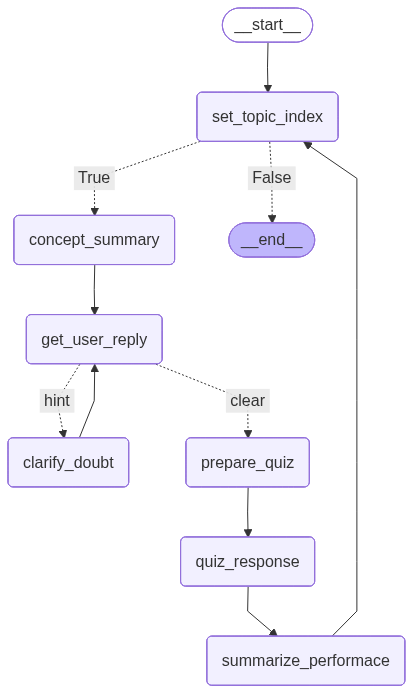

In [38]:
graph